
# Calculus and differential equations

In [1]:
import numpy as np
import matplotlib.pyplot as plt


## Functions to compute derivatives

In [2]:

def forward_deriv(f, x, a):
    return ( f(x+a) - f(x) )/a


def symmetric_central_deriv(f, x, a):
    return ( f(x+a) - f(x-a) )/(2*a)

print(forward_deriv(np.sin, 0.1, 1))
print(symmetric_central_deriv(np.sin, 0.1, 1))

0.7913739434146072
0.8372671348444594



## Check

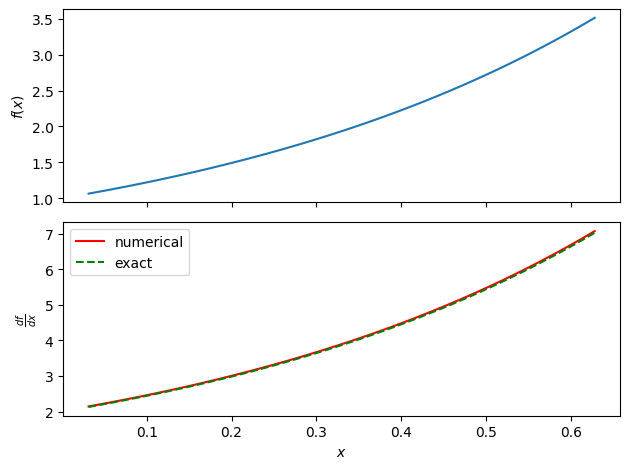

In [25]:

deriv = symmetric_central_deriv

# check what is a good value for a
a = .1
xs = np.linspace(.01*np.pi, .2*np.pi, 100)

def f(x):
    return np.exp(2*x)

def exact_df(x):
    return np.exp(2*x)*2 # 3*np.cos(3*x)

# calculate function
func = f(xs)

# calculate derivative, note that we just defined f, xs, and a above
dfunc = deriv(f, xs, a)

# calculate exact derivative
dfunc_exact = exact_df(xs) # your code here

fig, ax = plt.subplots(2, sharex=True)

# plot the function in the upper panel
ax[0].plot(xs, func)  # your code here

# plot the derivative in the lower panel
ax[1].plot(xs, dfunc, color='r', label='numerical') # your code here

# compare to exact derivative in the lower panel
ax[1].plot(xs, dfunc_exact, color='g',
           linestyle='--', label='exact') # your code here

# label for upper panel
ax[0].set_ylabel("$f(x)$")

# labels for lower panel
ax[1].set_xlabel("$x$")
ax[1].set_ylabel(r"$\frac{df}{dx}$")

plt.legend()

fig.tight_layout()
fig.show()


## Test convergence

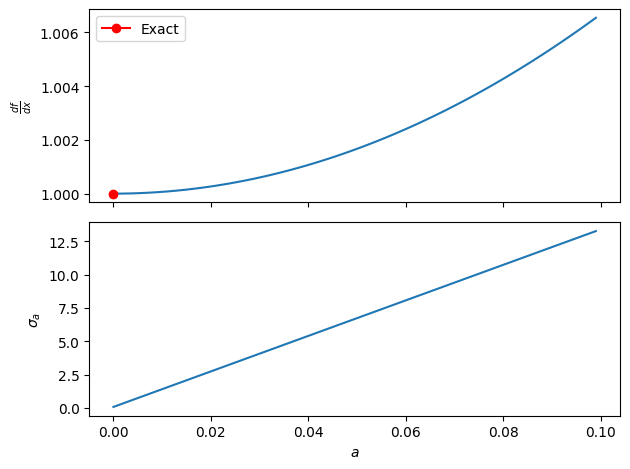

In [36]:

deriv = symmetric_central_deriv
astep = 1e-3

# create numpy array of "a" values
aes = np.arange(pow(10,-5),.1, astep)
aes = np.arange(10**(-5), .1, astep)

def f(x):
    return pow(x,3)/6 + pow(x,4)/8

# you can play with the value where we evaluate the derivative
x = 1
exact_der = pow(x,2)/2 + pow(x,3)/2

# how is this array different from the dfunc above?
fprimes = deriv(f, x, aes)

# what is this lambda keyword?
sigma = 100 * np.abs(forward_deriv(lambda a: deriv(f, x, a), aes, astep))

fig, ax = plt.subplots(2, sharex = True)

# plot the fprimes as a function of a
ax[0].plot(aes, fprimes) # your code here

# compare to exact value
ax[0].plot(exact_der, color="r", marker="o", label = "Exact")

# plot the sigmas
ax[1].plot(aes, sigma) # your code here

# label and legend for upper panel
ax[0].set_ylabel(r"$\frac{df}{dx}$")
ax[0].legend()

# labels for lower panel
ax[1].set_ylabel(r"$\sigma_a$")
ax[1].set_xlabel("$a$")


fig.tight_layout()
fig.show()


## Differential equation solver

In [ ]:

def solver(g, f0, xf, a):
    xs = np.arange(2*a, xf, 2*a)
    fs = [f0]

    for x in xs:
        fs.append # your code here

    return fs

In [ ]:

g = lambda x: np.cos(x)
exact = lambda x: np.sin(x)
f0 = 0
xf = 10
a = 1e-3

f = solver(g, f0, xf, a)
xs = np.arange(0, xf, 2*a)
fexact = exact(xs[::100])

fig, ax = plt.subplots()
ax.plot(xs, f)
ax.scatter(xs[::100], fexact, label = "Exact", c = "k")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$f(x)$")
ax.legend()
fig.tight_layout()
fig.show()


## Second order differential equation solver

In [ ]:

def solver(h, f0, g0, xf, a):
    xs = np.arange(2*a, xf, 2*a)
    fs = [f0]
    gs = [g0]

    for x in xs:
        gs.append # your code here
        fs.append # your code here

    return fs, gs

In [ ]:

h = lambda x: -1
f0 = 2
g0 = 1
exact = lambda x: f0 + g0*x - x**2/2
xf = 2.5
a = 1e-3

f, g = solver(h, f0, g0, xf, a)
xs = np.arange(0, xf, 2*a)
fexact = exact(xs[::100])

fig, ax = plt.subplots()
ax.plot(xs, f)
ax.scatter(xs[::100], fexact, label = "Exact", c = "k")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$f(x)$")
ax.legend()
fig.tight_layout()
fig.show()